# Controlling a stage and readout an interferometer using bluesky
awojdyla@lbl.gov, sdeleon@lbl.gov, khchan@lbl.gov, March 2026

In this notebook, we show how to control an experiment using the bluesky data acquisition framework. This notebook was tested using the Grating Writer computer in the ALS PSD Optics lab.

Make sure the `TILED_SINGLE_USER_API_KEY` is set in your environment variables, or that ypu have a file with the. do not sote that key in the notebook or in the repo.

In [1]:
## If needed, install the required packages in your Python environment using pip:

#!pip install pyepics
#!pip install ophyd
#!pip install newportxps

## Load useful packages

In [2]:
#using base 3.13.5 on GW
import numpy as np
import matplotlib.pyplot as plt

## Create instrument classes that work with bluesky
We create an ophyd wrapper for Newport XPS controller.

In [3]:
from ophyd import Device, Component as Cpt, Signal
from ophyd.status import SubscriptionStatus
import threading

class NewportXPSMotor(Device):
    # Ophyd signals
    user_readback = Cpt(Signal, value=0, kind='hinted')
    user_setpoint = Cpt(Signal, value=0, kind='normal')
    
    def __init__(self, ip_address, stage_name, username='Administrator', 
                 password='Administrator', *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        from newportxps import NewportXPS
        
        self.stage_name = stage_name
        self.group_name = stage_name.split('.')[0]  # Extract 'Group1' from 'Group1.Pos'
        self.xps = NewportXPS(ip_address, username=username, password=password)
        
        # Update initial position
        self._update_position()
        
    def _update_position(self):
        """Read current position from hardware"""
        pos = self.xps.read_stage_position(self.stage_name)
        self.user_readback.put(pos)
        return pos
    
    def _is_moving(self):
        """Check if the motor is currently moving"""
        status = self.xps.get_group_status()
        group_status = status.get(self.group_name, '')
        return 'Moving' in group_status
    
    def set(self, position, timeout=30):
        """Move to a position and return a status object"""
        
        def check_done(*, old_value, value, **kwargs):
            """Callback to check if motion is complete"""
            return not self._is_moving()
        
        # Start the move
        self.user_setpoint.put(position)
        self.xps.move_stage(self.stage_name, position)
        
        # Create a status object that monitors completion
        status = SubscriptionStatus(self.user_readback, check_done, timeout=timeout)
        
        # Start a background thread to update position during motion
        def monitor_motion():
            while not status.done:
                self._update_position()
                time.sleep(0.05)  # 50ms polling
            # Final position update
            self._update_position()
        
        thread = threading.Thread(target=monitor_motion, daemon=True)
        thread.start()
        
        return status
    
    def read(self):
        """Read current position"""
        pos = self._update_position()
        return {f'{self.name}_user_readback': {'value': pos, 'timestamp': time.time()}}
    
    def describe(self):
        """Describe the readback signal"""
        return {f'{self.name}_user_readback': {
            'source': f'XPS:{self.stage_name}',
            'dtype': 'number',
            'shape': []
        }}

## Instantiate the ophyd objects
We instantiate the ophyd objects so that they work with bluesky, and test whether they actually work.

In [4]:
from ophyd import EpicsSignal

#stock ophyd opbject for EPICS signal
interf = EpicsSignal('CATERETE:PICOSCALE:POS_0', name='interferometer_position')

#custom ophyd object
motor = NewportXPSMotor(
    ip_address='192.168.10.20',
    stage_name='Group1.Pos',
    username='Administrator',
    password='Administrator',
    name='xps_motor'
)

pos_inter_m = interf.get()*1e-12
pos_readback_m = motor.get()[0]*1e-3
print(f"Interferometer position: {pos_inter_m*1e3} mm")
print(f"Motor readback position: {pos_readback_m*1e3} mm")

Interferometer position: 1.422113778 mm
Motor readback position: 10.000002 mm


## Prepare data acquisitions

### connect to the tiled server
We first need to connect to the tiled server, so that the data can be saved and retrieved later on.

In [5]:
from tiled.client import from_uri
from bluesky.callbacks.tiled_writer import TiledWriter
from bluesky.callbacks.best_effort import BestEffortCallback
import os

#api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
api_key_filepath = "C:\\Users\\admin\\Documents\\TILED_SINGLE_USER_API_KEY.txt"
with open(api_key_filepath, 'r') as f:
    api_key = f.read().strip()
os.environ["TILED_SINGLE_USER_API_KEY"] = api_key

if not api_key:
   raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")
#from bluesky.callbacks.tiled_writer import TiledWriter

tiled_client = from_uri("http://192.168.10.240:8000/", api_key=api_key)
tw = TiledWriter(tiled_client)


In [6]:
# import os
# api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
# print(api_key)

### Start the bluesky runengine and subscribe it to the local
Start the bluesky runengine and subscribe it to the tiled server

In [7]:
from bluesky import RunEngine
from bluesky import plans as bp
import time

RE = RunEngine()
RE.subscribe(tw)

# for displaying data in the notebook
bec = BestEffortCallback()
RE.subscribe(bec)

1

### Acquire data
We just want to make sure we are able to acquire data, and then retrieve it



Transient Scan ID: 1     Time: 2026-03-27 10:12:47
Persistent Unique Scan ID: '14d22122-8b6c-483e-8bec-503aa2b913d9'
New stream: 'primary'
+-----------+------------+-------------------------+
|   seq_num |       time | interferometer_position |
+-----------+------------+-------------------------+
|         1 | 10:12:47.9 |              1422135145 |
|         2 | 10:12:48.0 |              1422114184 |
|         3 | 10:12:48.1 |              1422129997 |
|         4 | 10:12:48.1 |              1422143139 |
|         5 | 10:12:48.2 |              1422129781 |
|         6 | 10:12:48.2 |              1422126522 |
|         7 | 10:12:48.3 |              1422124189 |
|         8 | 10:12:48.4 |              1422131975 |
|         9 | 10:12:48.4 |              1422129639 |
|        10 | 10:12:48.5 |              1422119391 |
|        11 | 10:12:48.5 |              1422125473 |
+-----------+------------+-------------------------+
generator count ['14d22122'] (scan num: 1)





('14d22122-8b6c-483e-8bec-503aa2b913d9',)

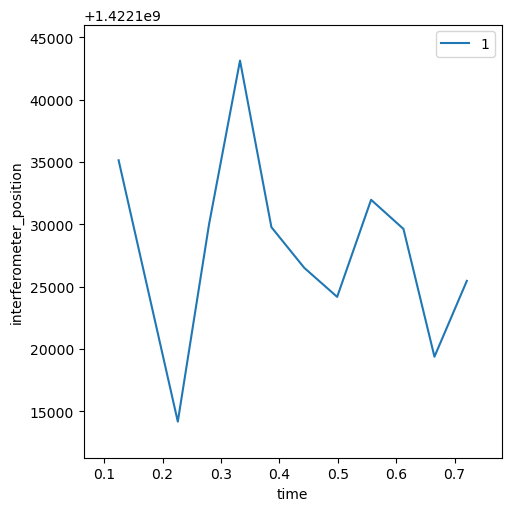

In [8]:
RE(bp.count([interf], 11))

### Retrieve data
Now that the data has been acquired, we should be able to retrieve it from anywhere.

In [9]:
# if needed:
#from tiled.client import from_uri
#api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
#api_key_filepath = "C:\\Users\\admin\\Documents\\TILED_SINGLE_USER_API_KEY.txt"
#with open(api_key_filepath, 'r') as f:
#     api_key = f.read().strip()
#tiled_client = from_uri("http://192.168.10.240:8000/", api_key=api_key)

#### load the data remotely 

In [10]:
db = tiled_client['c04cb241-4777-492d-9396-9307d5926938']
db['primary'].read()

<xarray.Dataset> Size: 176B
Dimensions:                  (dim0: 11)
Dimensions without coordinates: dim0
Data variables:
    interferometer_position  (dim0) int64 88B -463918512 ... -463923088
    time                     (dim0) float64 88B 1.775e+09 ... 1.775e+09

#### display the data

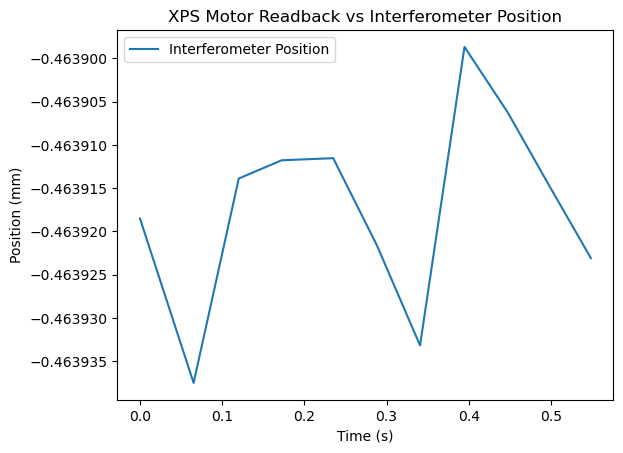

In [11]:
time_s = db['primary']['time'].read()
time0_s = time_s - time_s[0]
interferometer_position = db['primary']['interferometer_position'].read()
plt.plot(time0_s, interferometer_position*1e-9, label='Interferometer Position')
plt.xlabel('Time (s)')
plt.ylabel('Position (mm)')
plt.title('XPS Motor Readback vs Interferometer Position')
plt.legend()
plt.show()

## Linear motor scan
Now we perform a regular scan (that's feeding the runengine with `scan` imported from existigng bluesky plans)



Transient Scan ID: 2     Time: 2026-03-27 10:12:49
Persistent Unique Scan ID: 'fe1d013d-a908-49d6-a29c-2ce7781daf5c'
New stream: 'primary'
+-----------+------------+-------------------------+-------------------------+
|   seq_num |       time | xps_motor_user_readback | interferometer_position |
+-----------+------------+-------------------------+-------------------------+
|         1 | 10:13:30.0 |                 -10.000 |             -1395637699 |
|         2 | 10:13:34.1 |                  -8.000 |               603027222 |
|         3 | 10:13:38.3 |                  -6.000 |             -1691026469 |
|         4 | 10:13:42.4 |                  -4.000 |               306275151 |
|         5 | 10:13:46.5 |                  -2.000 |             -1986383059 |
|         6 | 10:13:50.6 |                   0.000 |                12253076 |
|         7 | 10:13:54.7 |                   2.000 |              2009400102 |
|         8 | 10:13:58.8 |                   4.000 |              -28

('fe1d013d-a908-49d6-a29c-2ce7781daf5c',)

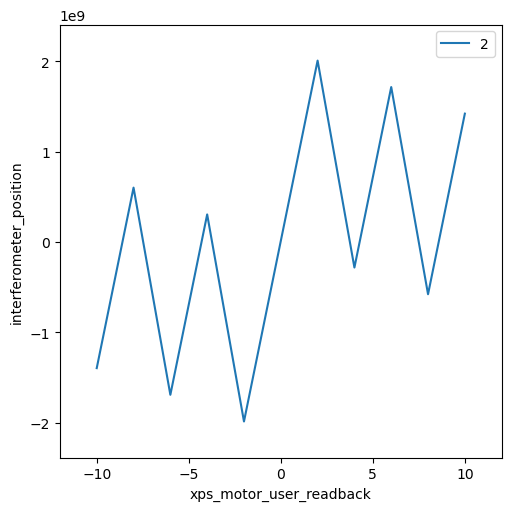

In [12]:
RE(bp.scan([interf, motor], motor, -10, 10, 11))

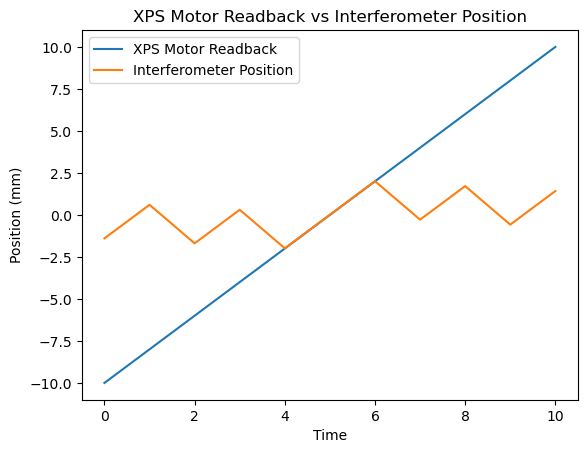

In [14]:
import matplotlib.pyplot as plt

db = tiled_client['fe1d013d-a908-49d6-a29c-2ce7781daf5c']

xps_motor_user_readback = db['primary']['xps_motor_user_readback'].read()
interferometer_position = db['primary']['interferometer_position'].read()
plt.plot(xps_motor_user_readback, label='XPS Motor Readback')
plt.plot(interferometer_position*1e-9, label='Interferometer Position')
plt.xlabel('Time')
plt.ylabel('Position (mm)')
plt.title('XPS Motor Readback vs Interferometer Position')
plt.legend()
plt.show()